# MNIST Multi-Class Classification Metrics

In [1]:
# Import Libraries

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)


In [3]:
# Load Dataset

# Change path if running outside Kaggle
df = pd.read_csv(r"C:\Users\divya\OneDrive\DS\EDA\digit-recognizer\train.csv")

# Display first 5 rows
df.head()


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# Dataset Shape

print("Shape of Dataset:", df.shape)


Shape of Dataset: (42000, 785)


In [5]:
# Features and Target

X = df.iloc[:, 1:]
y = df.iloc[:, 0]

print(X.shape)
print(y.shape)


(42000, 784)
(42000,)


In [6]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2
)


In [7]:
# Feature Scaling for Logistic Regression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [8]:
# Models

# Increased max_iter to avoid convergence warning
clf1 = LogisticRegression(max_iter=1000)

clf2 = DecisionTreeClassifier(random_state=2)


In [9]:
# Train Models

clf1.fit(X_train_scaled, y_train)

clf2.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,2
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [10]:
# Predictions

y_pred1 = clf1.predict(X_test_scaled)

y_pred2 = clf2.predict(X_test)


In [11]:
# Accuracy Scores

print("Accuracy of Logistic Regression:")
print(accuracy_score(y_test, y_pred1))

print("\nAccuracy of Decision Tree:")
print(accuracy_score(y_test, y_pred2))


Accuracy of Logistic Regression:
0.9051190476190476

Accuracy of Decision Tree:
0.8538095238095238


In [12]:
# Logistic Regression Confusion Matrix

print("Logistic Regression Confusion Matrix\n")

pd.DataFrame(
    confusion_matrix(y_test, y_pred1),
    columns=list(range(0,10))
)


Logistic Regression Confusion Matrix



,0,1,2,3,4,5,6,7,8,9
0,785,0,0,1,0,17,9,1,7,1
1,0,932,5,5,0,5,0,3,12,0
2,3,10,731,22,11,6,13,14,13,6
3,1,4,22,753,3,34,3,10,21,13
4,2,6,6,1,788,2,13,7,7,24
5,15,3,7,19,14,617,7,10,27,10
6,12,4,16,1,5,14,782,0,5,0
7,3,3,14,5,4,0,0,805,5,34
8,13,12,12,20,4,23,6,5,681,17
9,4,4,3,16,24,9,0,39,6,729


In [13]:
# Decision Tree Confusion Matrix

print("Decision Tree Confusion Matrix\n")

pd.DataFrame(
    confusion_matrix(y_test, y_pred2),
    columns=list(range(0,10))
)


Decision Tree Confusion Matrix



,0,1,2,3,4,5,6,7,8,9
0,756,1,13,6,2,17,11,3,8,4
1,1,903,11,8,6,7,3,8,10,5
2,9,16,671,43,13,13,15,18,26,5
3,6,6,31,696,9,43,9,18,28,18
4,5,5,14,5,729,9,16,6,18,49
5,14,7,12,40,8,587,17,9,24,11
6,9,2,8,7,11,27,755,2,13,5
7,2,10,23,13,7,4,0,785,8,21
8,9,10,31,39,16,33,13,6,609,27
9,6,5,9,22,39,20,4,24,24,681


In [14]:
# Logistic Regression Metrics

print("Precision Score")
print(precision_score(y_test, y_pred1, average='weighted'))

print("\nRecall Score")
print(recall_score(y_test, y_pred1, average='weighted'))

print("\nF1 Score")
print(f1_score(y_test, y_pred1, average='weighted'))


Precision Score
0.9049096686203139

Recall Score
0.9051190476190476

F1 Score
0.9049602812967167


In [17]:
# Logistic Regression Metrics

print("Precision Score")
print(precision_score(y_test, y_pred1, average='macro'))

print("\nRecall Score")
print(recall_score(y_test, y_pred1, average='macro'))

print("\nF1 Score")
print(f1_score(y_test, y_pred1, average='macro'))


Precision Score
0.9033228903889405

Recall Score
0.9032239255743443

F1 Score
0.9032206956076385


In [20]:
from sklearn.metrics import precision_score,recall_score
precision_score(y_test,y_pred1,average=None)

array([0.93675418, 0.95296524, 0.89583333, 0.89323843, 0.92379836,
       0.84869326, 0.93877551, 0.90044743, 0.86862245, 0.87410072])

In [15]:
# Classification Report

print(classification_report(y_test, y_pred1))


              precision    recall  f1-score   support

           0       0.94      0.96      0.95       821
           1       0.95      0.97      0.96       962
           2       0.90      0.88      0.89       829
           3       0.89      0.87      0.88       864
           4       0.92      0.92      0.92       856
           5       0.85      0.85      0.85       729
           6       0.94      0.93      0.94       839
           7       0.90      0.92      0.91       873
           8       0.87      0.86      0.86       793
           9       0.87      0.87      0.87       834

    accuracy                           0.91      8400
   macro avg       0.90      0.90      0.90      8400
weighted avg       0.90      0.91      0.90      8400



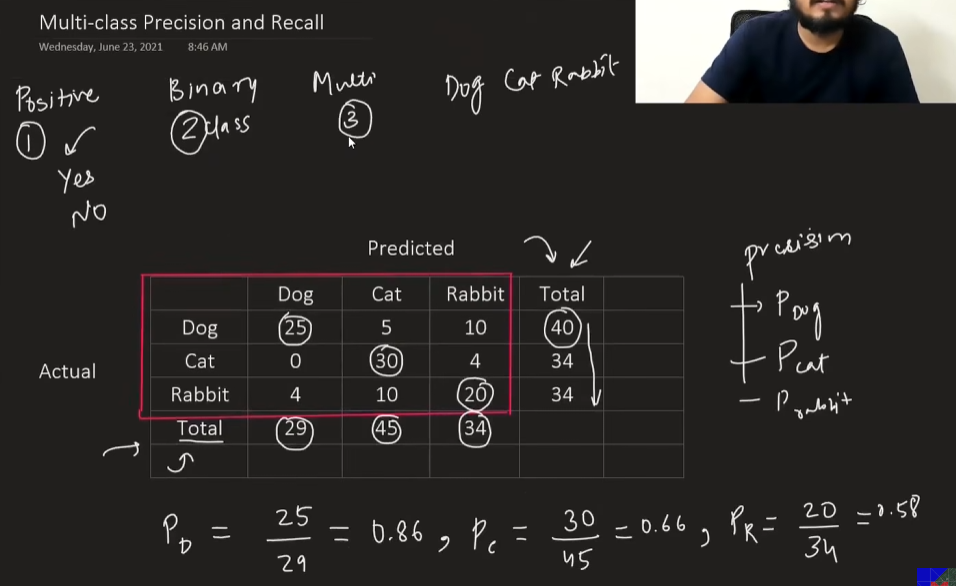

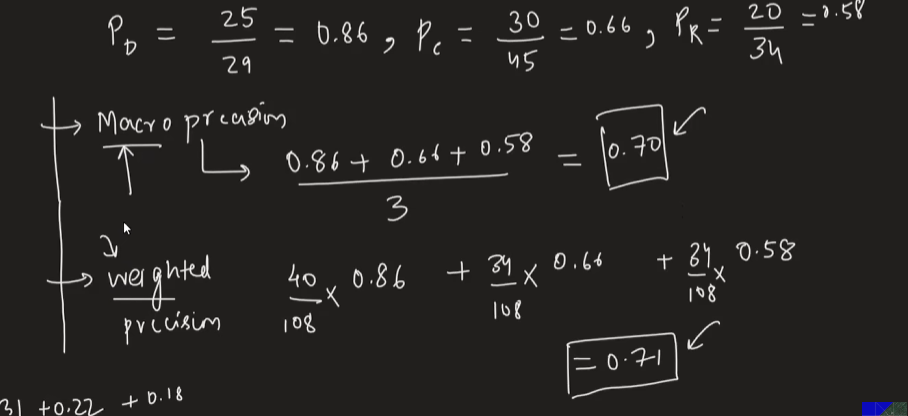

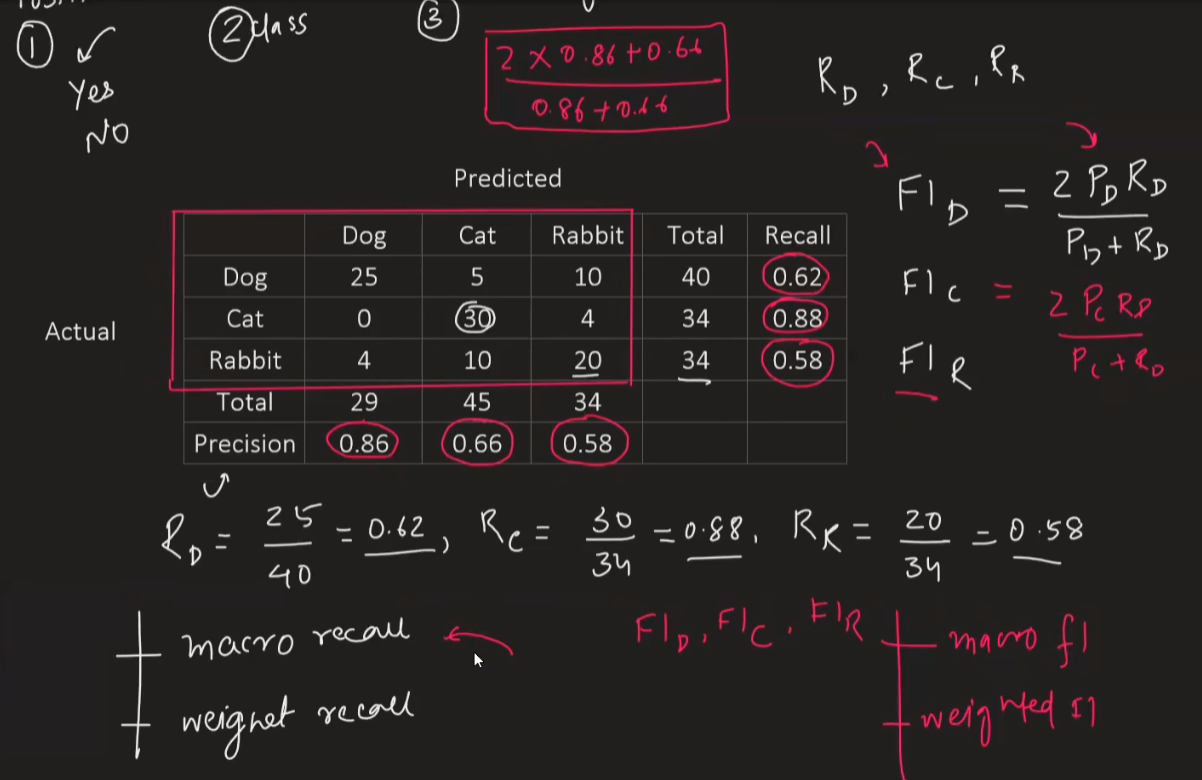